# ⚡ US Power Outages Analysis — 2023
**Dataset:** EAGLE-I (Oak Ridge National Laboratory) — 77,341 records  
**Technology:** PySpark + MLlib  

---

### 📋 What this notebook does:
1. Installs and configures PySpark on Colab
2. Loads the CSV directly from Google Drive
3. Performs exploratory data analysis on the outages
4. Trains a **Random Forest** to classify the event type
5. Trains a **Linear Regression** to predict outage duration
6. Displays metrics, charts, and final insights

## 🔧 1 — Install PySpark

In [2]:
# Install PySpark (required once per Colab session)
!pip install pyspark==4.0.0 -q
print('✓ PySpark installed successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 MB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 17.9 MB/s eta 0:00:00
✓ PySpark installed successfully!


## 📂 2 — Mount Google Drive and locate the file
> **Instructions:** Upload `eaglei_outages_with_events_2023.csv` to any folder in your Google Drive.  
> Colab will ask for access permission — click **Connect to Google Drive** and authorize your account.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Automatically search for the file anywhere in Drive
print('🔍 Searching for the dataset in Google Drive...')
result = !find /content/drive/MyDrive -name 'eaglei_outages_with_events_2023.csv' 2>/dev/null

if result:
    CSV_PATH = result[0]
    print(f'✓ File found at:\n  {CSV_PATH}')
else:
    # If not found automatically, set the path manually
    CSV_PATH = '/content/drive/MyDrive/eaglei_outages_with_events_2023.csv'
    print('⚠️  File not found automatically.')
    print(f'   Please check that the CSV is uploaded to Drive and update CSV_PATH manually.')
    print(f'   Default path set to: {CSV_PATH}')

Mounted at /content/drive
🔍 Searching for the dataset in Google Drive...
✓ File found at:
  /content/drive/MyDrive/Colab Notebooks/PySpark_Outages1/eaglei_outages_with_events_2023.csv


## ⚡ 3 — Start SparkSession

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('USPowerOutages_2023') \
    .master('local[*]') \
    .config('spark.sql.legacy.timeParserPolicy', 'LEGACY') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')

print('=' * 55)
print('  SPARKSESSION STARTED')
print(f'  Spark version : {spark.version}')
print(f'  Mode          : local (all available CPUs)')
print('=' * 55)

  SPARKSESSION STARTED
  Spark version : 4.0.0
  Mode          : local (all available CPUs)


## 📊 4 — Load and inspect the data

In [5]:
df_raw = spark.read.csv(
    CSV_PATH,
    header=True,
    inferSchema=True
)

total = df_raw.count()
print(f'Total records  : {total:,}')
print(f'Total columns  : {len(df_raw.columns)}')
print()
print('Detected schema:')
df_raw.printSchema()

print('First 5 rows:')
df_raw.show(5, truncate=35)

Total records  : 77,341
Total columns  : 14

Detected schema:
root
 |-- event_id: string (nullable = true)
 |-- state_event: string (nullable = true)
 |-- Datetime Event Began: string (nullable = true)
 |-- Datetime Restoration: string (nullable = true)
 |-- Event Type: string (nullable = true)
 |-- fips: integer (nullable = true)
 |-- state: string (nullable = true)
 |-- county: string (nullable = true)
 |-- start_time: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- end_time: string (nullable = true)
 |-- min_customers: integer (nullable = true)
 |-- max_customers: integer (nullable = true)
 |-- mean_customers: double (nullable = true)

First 5 rows:
+---------+-----------+--------------------+--------------------+--------------+----+-------+-------+-------------------+--------+-------------------+-------------+-------------+------------------+
| event_id|state_event|Datetime Event Began|Datetime Restoration|    Event Type|fips|  state| county|         start_tim

## 🧹 5 — Data Cleaning and Feature Engineering

In [6]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

df = df_raw \
    .withColumnRenamed('Event Type',             'event_type') \
    .withColumnRenamed('Datetime Event Began',   'event_began') \
    .withColumnRenamed('Datetime Restoration',   'event_restoration') \
    .withColumn('duration',       F.col('duration').cast(DoubleType())) \
    .withColumn('min_customers',  F.col('min_customers').cast(DoubleType())) \
    .withColumn('max_customers',  F.col('max_customers').cast(DoubleType())) \
    .withColumn('mean_customers', F.col('mean_customers').cast(DoubleType())) \
    .withColumn('start_time', F.to_timestamp('start_time', 'yyyy-MM-dd HH:mm:ss')) \
    .withColumn('end_time',   F.to_timestamp('end_time',   'yyyy-MM-dd HH:mm:ss')) \
    .withColumn('hour_of_day',    F.hour('start_time').cast(DoubleType())) \
    .withColumn('day_of_week',    F.dayofweek('start_time').cast(DoubleType())) \
    .withColumn('month',          F.month('start_time').cast(DoubleType())) \
    .withColumn('customers_range',
        (F.col('max_customers') - F.col('min_customers')).cast(DoubleType())) \
    .filter(F.col('duration').isNotNull()      & (F.col('duration') > 0)) \
    .filter(F.col('max_customers').isNotNull() & (F.col('max_customers') > 0)) \
    .filter(F.col('event_type').isNotNull())

# Normalize event type categories
df = df.withColumn(
    'event_type_clean',
    F.when(F.col('event_type').contains('Weather'),      'Severe Weather')
     .when(F.col('event_type').contains('Vandal'),       'Vandalism')
     .when(F.col('event_type').contains('Suspicious'),   'Suspicious Activity')
     .when(F.col('event_type').contains('System'),       'System Operations')
     .when(F.col('event_type').contains('Transmission'), 'Transmission')
     .otherwise('Other')
)

df.cache()
clean_count = df.count()
print(f'Records after cleaning : {clean_count:,}')
print(f'Records removed        : {total - clean_count:,}')
print()
print('Event type distribution:')
df.groupBy('event_type_clean').count().orderBy(F.desc('count')).show()

Records after cleaning : 77,341
Records removed        : 0

Event type distribution:
+-------------------+-----+
|   event_type_clean|count|
+-------------------+-----+
|     Severe Weather|61341|
|          Vandalism| 6012|
|Suspicious Activity| 3583|
|              Other| 3197|
|       Transmission| 1674|
|  System Operations| 1534|
+-------------------+-----+



## 🔍 6 — Exploratory Data Analysis

In [8]:
print('━' * 55)
print('  TOP 10 STATES BY NUMBER OF OUTAGES')
print('━' * 55)
df.groupBy('state') \
  .agg(
      F.count('*').alias('total_outages'),
      F.round(F.avg('duration'), 2).alias('avg_duration[h]'),
      F.round(F.avg('max_customers'), 0).alias('avg_customers_affected'),
  ) \
  .orderBy(F.desc('total_outages')) \
  .show(10)

print('━' * 55)
print('  BREAKDOWN BY EVENT TYPE')
print('━' * 55)
df.groupBy('event_type_clean') \
  .agg(
      F.count('*').alias('occurrences'),
      F.round(F.avg('duration'), 2).alias('avg_duration[h]'),
      F.round(F.sum('max_customers') / 1_000_000, 2).alias('total_customers[M]'),
  ) \
  .orderBy(F.desc('occurrences')) \
  .show()

print('━' * 55)
print('  OUTAGES BY MONTH')
print('━' * 55)
df.groupBy('month') \
  .agg(F.count('*').alias('outages')) \
  .orderBy('month') \
  .show(12)

print('━' * 55)
print('  DURATION STATISTICS (hours)')
print('━' * 55)
df.select('duration').describe().show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 10 STATES BY NUMBER OF OUTAGES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+----------+-------------+---------------+----------------------+
|     state|total_outages|avg_duration[h]|avg_customers_affected|
+----------+-------------+---------------+----------------------+
|     Texas|        49096|           4.66|                1542.0|
|  Kentucky|         8100|          18.13|                1902.0|
|  Michigan|         3815|          11.83|                3003.0|
|California|         3369|           3.69|                1563.0|
|   Florida|         1356|           1.84|                1415.0|
|  Virginia|         1159|           3.25|                 995.0|
|   Georgia|         1022|           5.65|                1759.0|
|  Maryland|          940|           1.09|                2231.0|
|  Illinois|          935|           5.66|                1420.0|
| Wisconsin|          774|          10.03|                3

## 📈 7 — Visualizations with Matplotlib
> In Colab, we use `toPandas()` to convert Spark DataFrames and plot inline.

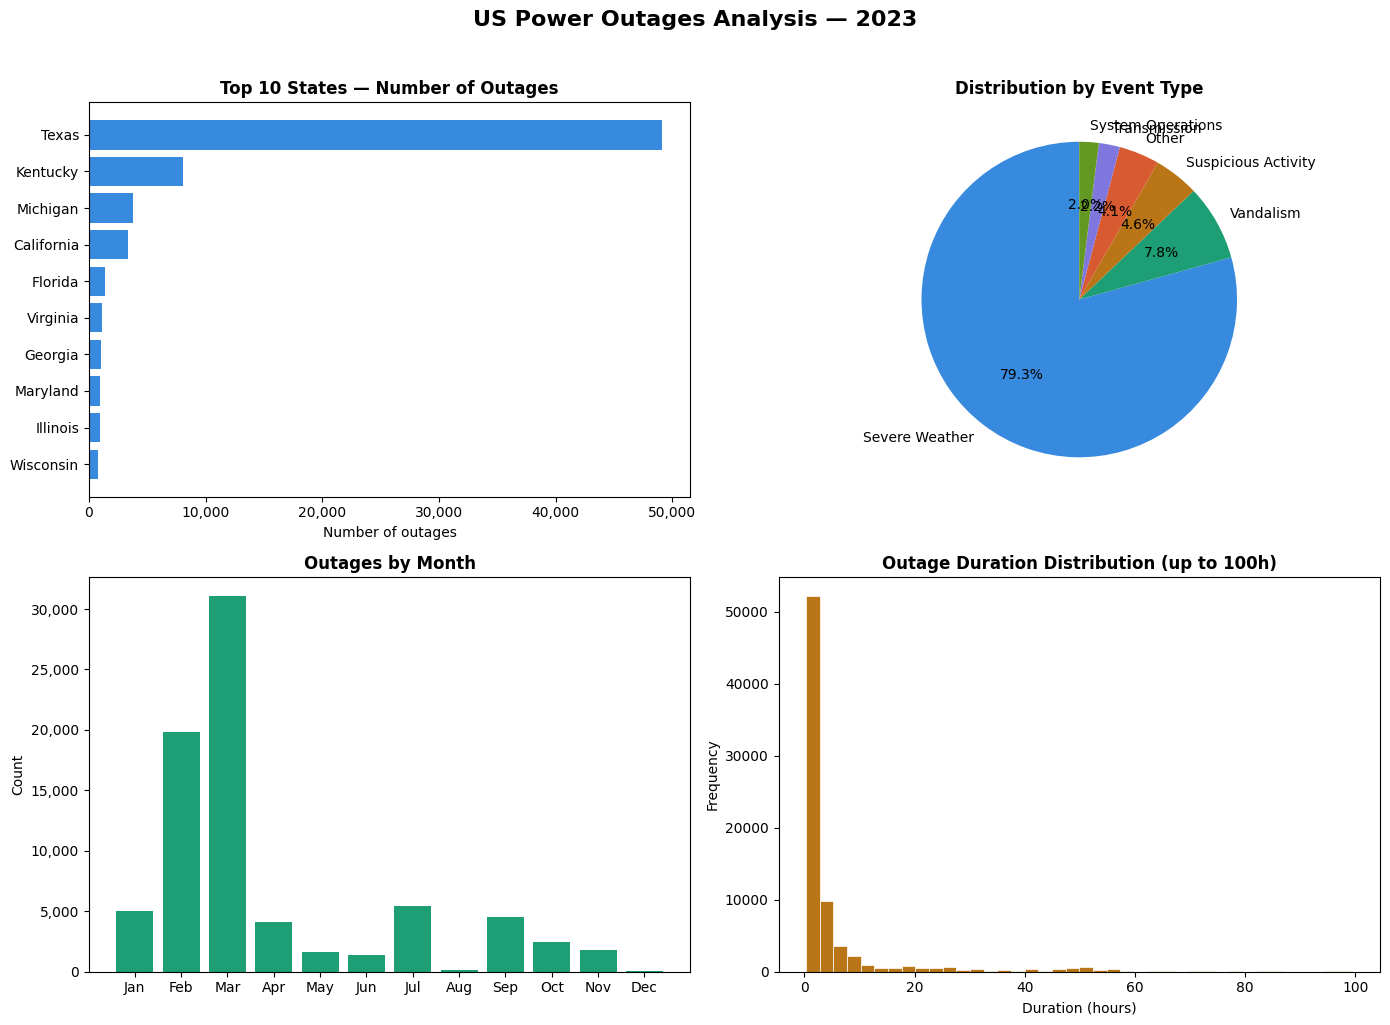

✓ Chart saved as outages_charts.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('US Power Outages Analysis — 2023', fontsize=16, fontweight='bold', y=1.02)

# --- Chart 1: Top 10 states ---
top_states = df.groupBy('state') \
    .count() \
    .orderBy(F.desc('count')) \
    .limit(10) \
    .toPandas()

axes[0,0].barh(top_states['state'][::-1], top_states['count'][::-1], color='#378ADD')
axes[0,0].set_title('Top 10 States — Number of Outages', fontweight='bold')
axes[0,0].set_xlabel('Number of outages')
axes[0,0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Chart 2: Event type breakdown ---
event_types = df.groupBy('event_type_clean') \
    .count() \
    .orderBy(F.desc('count')) \
    .toPandas()

colors = ['#378ADD','#1D9E75','#BA7517','#D85A30','#7F77DD','#639922']
axes[0,1].pie(
    event_types['count'],
    labels=event_types['event_type_clean'],
    colors=colors[:len(event_types)],
    autopct='%1.1f%%',
    startangle=90
)
axes[0,1].set_title('Distribution by Event Type', fontweight='bold')

# --- Chart 3: Outages by month ---
months_df = df.groupBy('month') \
    .count() \
    .orderBy('month') \
    .toPandas()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months_df['month_name'] = months_df['month'].apply(lambda x: month_names[int(x)-1])
axes[1,0].bar(months_df['month_name'], months_df['count'], color='#1D9E75')
axes[1,0].set_title('Outages by Month', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Chart 4: Duration distribution ---
durations = df.filter(F.col('duration') <= 100) \
    .select('duration') \
    .toPandas()

axes[1,1].hist(durations['duration'], bins=40, color='#BA7517', edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Outage Duration Distribution (up to 100h)', fontweight='bold')
axes[1,1].set_xlabel('Duration (hours)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('outages_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart saved as outages_charts.png')

## 🤖 8 — Classification Model (Random Forest)
**Goal:** predict `event_type_clean` based on duration, customers affected, time of day, and date features.

In [10]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

print('Building classification pipeline...')

label_indexer = StringIndexer(
    inputCol='event_type_clean',
    outputCol='label',
    handleInvalid='skip'
)

feature_cols_clf = [
    'duration', 'max_customers', 'min_customers',
    'customers_range', 'hour_of_day', 'day_of_week', 'month'
]

assembler_clf = VectorAssembler(
    inputCols=feature_cols_clf,
    outputCol='features',
    handleInvalid='skip'
)

rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=50,
    maxDepth=8,
    seed=42
)

pipeline_clf = Pipeline(stages=[label_indexer, assembler_clf, rf])

train_clf, test_clf = df.randomSplit([0.8, 0.2], seed=42)
print(f'Training set : {train_clf.count():,} rows')
print(f'Test set     : {test_clf.count():,} rows')
print('Training Random Forest (please wait ~1 min)...')

model_clf = pipeline_clf.fit(train_clf)
pred_clf  = model_clf.transform(test_clf)

accuracy = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
).evaluate(pred_clf)

f1_score = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
).evaluate(pred_clf)

print()
print('━' * 45)
print('  RESULTS — CLASSIFICATION')
print('━' * 45)
print(f'  Accuracy : {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  F1-Score : {f1_score:.4f}')
print('━' * 45)

# Feature importance
rf_model    = model_clf.stages[-1]
importances = rf_model.featureImportances.toArray()
print()
print('Feature importance:')
for col, imp in sorted(zip(feature_cols_clf, importances), key=lambda x: -x[1]):
    bar = '█' * int(imp * 35)
    print(f'  {col:20s}: {bar} {imp:.4f}')

Building classification pipeline...
Training set : 61,930 rows
Test set     : 15,411 rows
Training Random Forest (please wait ~1 min)...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESULTS — CLASSIFICATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy : 0.8230  (82.3%)
  F1-Score : 0.7714
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Feature importance:
  month               : ██████████████████████████ 0.7654
  day_of_week         : ███ 0.1011
  duration            : █ 0.0480
  hour_of_day         : █ 0.0318
  customers_range     :  0.0192
  min_customers       :  0.0175
  max_customers       :  0.0169


## 📉 9 — Regression Model (Linear Regression)
**Goal:** predict `duration` (outage length in hours).

In [11]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

print('Building regression pipeline...')

feature_cols_reg = [
    'max_customers', 'min_customers', 'customers_range',
    'hour_of_day', 'day_of_week', 'month'
]

assembler_reg = VectorAssembler(
    inputCols=feature_cols_reg,
    outputCol='features_reg',
    handleInvalid='skip'
)

lr = LinearRegression(
    featuresCol='features_reg',
    labelCol='duration',
    maxIter=100,
    regParam=0.1
)

pipeline_reg = Pipeline(stages=[assembler_reg, lr])

train_reg, test_reg = df.randomSplit([0.8, 0.2], seed=42)
print('Training Linear Regression...')

model_reg = pipeline_reg.fit(train_reg)
pred_reg  = model_reg.transform(test_reg)

eval_reg = RegressionEvaluator(labelCol='duration', predictionCol='prediction')
rmse = eval_reg.evaluate(pred_reg, {eval_reg.metricName: 'rmse'})
mae  = eval_reg.evaluate(pred_reg, {eval_reg.metricName: 'mae'})
r2   = eval_reg.evaluate(pred_reg, {eval_reg.metricName: 'r2'})

print()
print('━' * 45)
print('  RESULTS — LINEAR REGRESSION')
print('━' * 45)
print(f'  RMSE : {rmse:.2f} hours')
print(f'  MAE  : {mae:.2f} hours')
print(f'  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print('━' * 45)
print()
print('Model coefficients (impact of each feature on duration):')
lr_model = model_reg.stages[-1]
for col, coef in zip(feature_cols_reg, lr_model.coefficients):
    print(f'  {col:20s}: {coef:+.4f}')
print(f'  {"intercept":20s}: {lr_model.intercept:+.4f}')

Building regression pipeline...
Training Linear Regression...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESULTS — LINEAR REGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RMSE : 13.33 hours
  MAE  : 6.74 hours
  R²   : 0.2807  (28.1% variance explained)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Model coefficients (impact of each feature on duration):
  max_customers       : +0.0006
  min_customers       : -0.0013
  customers_range     : +0.0006
  hour_of_day         : +0.0176
  day_of_week         : +0.8101
  month               : -0.4787
  intercept           : +3.3944


## 🏆 10 — Final Insights

In [12]:
print('━' * 55)
print('  TOP 5 MOST AFFECTED COUNTIES')
print('━' * 55)
df.groupBy('state', 'county') \
  .agg(F.round(F.sum('max_customers') / 1_000, 1).alias('total_customers_k')) \
  .orderBy(F.desc('total_customers_k')) \
  .show(5)

print('━' * 55)
print('  HOURS OF DAY WITH MOST OUTAGES')
print('━' * 55)
df.groupBy('hour_of_day') \
  .count() \
  .orderBy(F.desc('count')) \
  .show(5)

print('━' * 55)
print('  TOP 5 LONGEST OUTAGES ON RECORD')
print('━' * 55)
df.select('state', 'county', 'event_type_clean', 'duration', 'max_customers') \
  .orderBy(F.desc('duration')) \
  .show(5)

print()
print('=' * 55)
print('  ✅ ANALYSIS COMPLETED SUCCESSFULLY!')
print('=' * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 5 MOST AFFECTED COUNTIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-----+----------+-----------------+
|state|    county|total_customers_k|
+-----+----------+-----------------+
|Texas|    Travis|           6891.8|
|Texas|    Dallas|           6700.1|
|Texas|   Tarrant|           6667.4|
|Texas|Williamson|           3229.0|
|Texas|    Collin|           3139.9|
+-----+----------+-----------------+
only showing top 5 rows
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HOURS OF DAY WITH MOST OUTAGES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-----------+-----+
|hour_of_day|count|
+-----------+-----+
|       17.0| 5275|
|       21.0| 5240|
|       19.0| 4609|
|       22.0| 4583|
|       20.0| 4550|
+-----------+-----+
only showing top 5 rows
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 5 LONGEST OUTAGES ON RECORD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+----

## 💾 11 — Save chart back to Google Drive (optional)

In [13]:
import shutil, os

# Save the chart generated in Cell 7 back to Google Drive
destination = '/content/drive/MyDrive/outages_charts_2023.png'

if os.path.exists('outages_charts.png'):
    shutil.copy('outages_charts.png', destination)
    print(f'✓ Chart saved to Drive: {destination}')
else:
    print('⚠️  Please run Cell 7 first to generate the chart.')

✓ Chart saved to Drive: /content/drive/MyDrive/outages_charts_2023.png


## 🔴 12 — Stop SparkSession

In [ ]:
spark.stop()
print('✓ SparkSession stopped.')